In [1]:
import torch

if torch.cuda.is_available():
    print("CUDA is available!")
    device = torch.device('cuda')
else:
    print("CUDA is not available. Using CPU.")
    device = torch.device('cpu')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import os
import json
import pickle

import tkinter as tk
import pandas as pd
import cv2
import torch
import torchvision

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler

CUDA is not available. Using CPU.


import torch: Импортирует библиотеку PyTorch для работы с нейронными сетями.
Определение устройства (device):
Проверяет, доступна ли CUDA (GPU) с помощью torch.cuda.is_available().
Если CUDA доступна, устанавливает device на 'cuda', чтобы использовать GPU.
Иначе, устанавливает device на 'cpu', чтобы использовать CPU.
Импорт библиотек: Импортирует необходимые библиотеки для:
Численных вычислений (numpy).
Визуализации (matplotlib.pyplot).
Работы с файловой системой (os).
Работы с данными в формате JSON (json) и pickle (pickle).
Создания графического интерфейса (tkinter).
Работы с табличными данными (pandas).
Обработки изображений (cv2).
Дополнительных модулей PyTorch (torch.nn, torch.nn.functional, torch.optim, torch.optim.lr_scheduler).

In [3]:
#pip install opencv-python-headless

In [3]:
#pip install torch torchvision torchaudio


In [4]:
#pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu/torchvision-0.17.1%2Bcpu-cp310-cp310-linux_x86_64.whl

# 0.Dataset/Corresponding labels/Classifier

In [2]:
"""
0.0 Reading mov of static image 
"""
###
if_rotate=False # Rotate 90 if needed
###
cap = cv2.VideoCapture("workspace_physical/static.mov")
frame_list=[]
while(cap.isOpened()):
    ret, frame = cap.read()
    
    if ret == True:
        if if_rotate:
            frame=cv2.rotate(frame, cv2.ROTATE_90_COUNTERCLOCKWISE)
        frame_list.append(frame)
    else:
        break
cap.release()

В итоге, этот код читает видеофайл “workspace_physical/static.mov”, извлекает все кадры, возможно, поворачивает их, и сохраняет их в список frame_list.

True

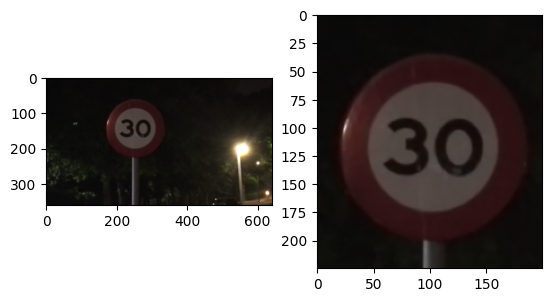

In [3]:
"""
0.1 Select bound for more quality result.
and store victim image 
"""
###
x_bound=(25,250)
y_bound=(150,350)
###

static_img=np.mean(frame_list,axis=0) # mean of multi frames to reduce noise
static_img=np.round(static_img)/255
plt.subplot(1,2,1)
plt.imshow(static_img[:,:,::-1])
plt.subplot(1,2,2)
plt.imshow(static_img[x_bound[0]:x_bound[1],y_bound[0]:y_bound[1]][:,:,::-1])

test_img=static_img[x_bound[0]:x_bound[1],y_bound[0]:y_bound[1]]
cv2.imwrite('workspace_physical/source.png', (test_img*255).astype("uint8"))

В итоге, этот код усредняет кадры из видео, обрезает область интереса, отображает исходное и обрезанное изображения, и сохраняет обрезанное изображение в файл “workspace_physical/source.png”.

In [4]:
"""
0.2 Reading dictionary of label
"""
###
DATASET="RTSD"
###
with open("params.json", "r") as config:
    params = json.load(config)
    CLASS_N = params[DATASET]["class_n"]
    LABELS = params[DATASET]["labels"]
    CLASSIFIER_INPUT_SHAPE=params[DATASET]["classifier_input_shape"]
    device = params["device"]

In [5]:
class GTSRB_MODEL(nn.Module):
    def __init__(self, output_dim):
        """
        Initializing the model
        """

        super(GTSRB_MODEL,self).__init__()
        self.input_dim = 3*50*50
        self.output_dim = output_dim

        self.metrics = {}

        self.flatten = nn.Flatten()

        self.dropout2 = nn.Dropout(0.2)
        self.dropout3 = nn.Dropout(0.3)

        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(2)

        # building layers
        self.conv1 = nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,padding=1)
        self.conv2 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1)
        self.batchnorm1 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1)
        self.conv4 = nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,padding=1)
        self.batchnorm2 = nn.BatchNorm2d(256)

        self.conv5 = nn.Conv2d(in_channels=256,out_channels=512,kernel_size=3)
        self.conv6 = nn.Conv2d(in_channels=512,out_channels=1024,kernel_size=3)
        self.batchnorm3 = nn.BatchNorm2d(1024)


        self.l1 = nn.Linear(1024*4*4,512)
        self.l2 = nn.Linear(512,128)
        self.batchnorm4 = nn.LayerNorm(128)
        self.l3 = nn.Linear(128,output_dim)


    def forward(self, input):
        """
        Forward propagation...
        """

        conv = self.conv1(input)
        conv = self.conv2(conv)
        batchnorm = self.relu(self.batchnorm1(conv))
        maxpool = self.maxpool(batchnorm)

        conv = self.conv3(maxpool)
        conv = self.conv4(conv)
        batchnorm = self.relu(self.batchnorm2(conv))
        maxpool = self.maxpool(batchnorm)

        conv = self.conv5(maxpool)
        conv = self.conv6(conv)
        batchnorm = self.relu(self.batchnorm3(conv))
        maxpool = self.maxpool(batchnorm)

        flatten = self.flatten(maxpool)

        dense_l1 = self.l1(flatten)
        dropout = self.dropout3(dense_l1)
        dense_l2 = self.l2(dropout)
        batchnorm = self.batchnorm4(dense_l2)
        dropout = self.dropout2(batchnorm)
        output = self.l3(dropout)


        return output

In [6]:
"""
0.3 Reading model of corresponding classifer 
"""
#from model import GTSRB_MODEL
###
CLASSIFIER_MODEL=GTSRB_MODEL
CLASSIFIER_PATH="model/cnn_rtsd_final.pt"
###
print("CUDA Available: ", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:",device)

classifier = CLASSIFIER_MODEL(CLASS_N).to(device)
if torch.cuda.is_available():
    classifier.load_state_dict(torch.load(CLASSIFIER_PATH))
else:
    classifier.load_state_dict(torch.load(CLASSIFIER_PATH, map_location=torch.device('cpu')))
print("Classifier Path =", CLASSIFIER_PATH)


CUDA Available:  False
Device: cpu


Classifier Path = model/cnn_rtsd_final.pt


КУСОК ИЗ ДРУГОГО КОДА

In [7]:
import torch
import torchvision.transforms as transforms
from PIL import Image  # Для загрузки изображений
import numpy as np
import torch.nn.functional as F # for loss function


# 1. Загрузка модели
def load_model(model_path, device='cpu'):
    """Загружает PyTorch модель с указанного пути."""
    # 1. Создаем экземпляр модели
    INPUT_DIM = 3 * 50 * 50  # Замените на правильное значение
    OUTPUT_DIM = 106  # Замените на правильное значение
    model = GTSRB_MODEL(OUTPUT_DIM).to(device)

    # 2. Загружаем state_dict в модель
    model.load_state_dict(torch.load(model_path, map_location=torch.device(device)))

    # 3. Переводим модель в режим eval
    model.eval()
    return model


# 2. Предобработка изображений (должна соответствовать предобработке, использованной при обучении модели!)
def preprocess_image(image_path, img_size=(50, 50)): # Замените (32,32) на размер, используемый при обучении
    """Предобрабатывает изображение."""
    try:
        img = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f"Error: Image not found at {image_path}")
        return None
    except Exception as e:
        print(f"Error opening image: {e}")
        return None

    transform = transforms.Compose([
        transforms.Resize(img_size), # Resize if needed
        transforms.ToTensor()
    ])

    img_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    return img_tensor

In [8]:
import torch
import torch.nn.functional as F

def check_photo(model_path, image_path, device='cpu'):
    """
    Пропускает изображение через модель и возвращает предсказанный класс и уверенность.

    Args:
        model_path (str): Путь к файлу модели.
        image_path (str): Путь к файлу изображения.
        device (str): Устройство для выполнения вычислений ('cpu' или 'cuda').

    Returns:
        tuple: (predicted_class, confidence_score), или (None, None) в случае ошибки.
    """
    # 1. Загрузка модели
    model = load_model(model_path, device)

    # 2. Предобработка изображения
    image_tensor = preprocess_image(image_path)
    if image_tensor is None:
        return None, None

    # 3. Пропускаем изображение через модель (без атаки)
    with torch.no_grad():  # Отключаем вычисление градиентов
        output = model(image_tensor.to(device))
        _, predicted_class = torch.max(output.data, 1)
        confidence = F.softmax(output, dim=1)
        confidence_score = confidence.max().item()

    # Возвращаем предсказанный класс и уверенность модели
    return predicted_class.item(), confidence_score



Predicted class: 79
Confidence: 1.0000


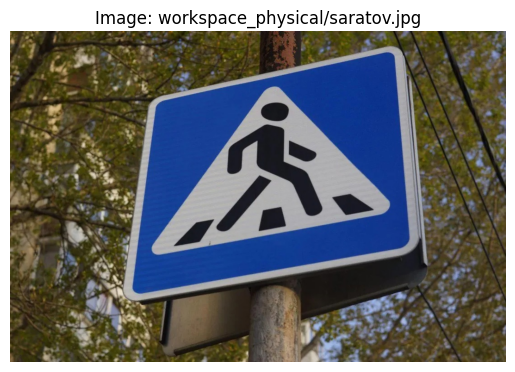

In [9]:
# Пример использования
model_path = 'model/cnn_rtsd_final.pt'
image_path = "workspace_physical/saratov.jpg"  # Замени на путь к файлу изображения

predicted_class, confidence = check_photo(model_path, image_path)

if predicted_class is not None:
    print(f"Predicted class: {predicted_class}")
    print(f"Confidence: {confidence:.4f}")
else:
    print("Error processing image.")

try:
    img = Image.open(image_path)
    plt.imshow(img)
    plt.title(f"Image: {image_path}")
    plt.axis('off') # Turn off axes numbers
    plt.show()
except FileNotFoundError:
    print(f"Error: Image not found at {image_path}")
except Exception as e:
    print(f"Error displaying image: {e}")

(128, 128)


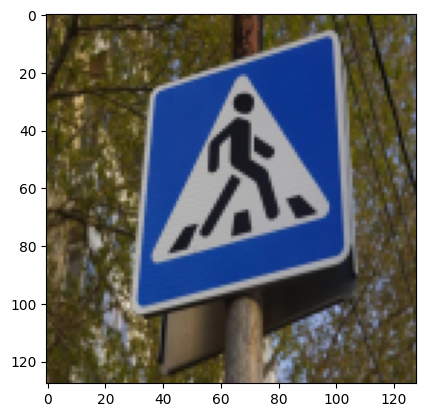

In [10]:
"""
0.4 Read in victim image and corresponding classification 
"""
###
RESIZED_SHAPE=(128,128) # influence the resolution of light generator and ZOO optimizer
###
test_img_ = cv2.imread("workspace_physical/saratov.jpg")
test_img = cv2.resize(test_img_, RESIZED_SHAPE, interpolation=cv2.INTER_AREA)
test_img=test_img.astype(np.float32)/255
###
print(test_img[:, :, 0].shape)
plt.imshow(test_img[:, :, ::-1])

Модель успешно загружена!
Predict: 79 Confidence: 100.00%
Top 1 (100.00%) = 79 ...
Top 2 (0.00%) = 84 ...
Top 3 (0.00%) = 80 ...
Top 4 (0.00%) = 36 ...
Top 5 (0.00%) = 23 ...
Top 6 (0.00%) = 54 ...
Top 7 (0.00%) = 0 ...
Top 8 (0.00%) = 27 ...


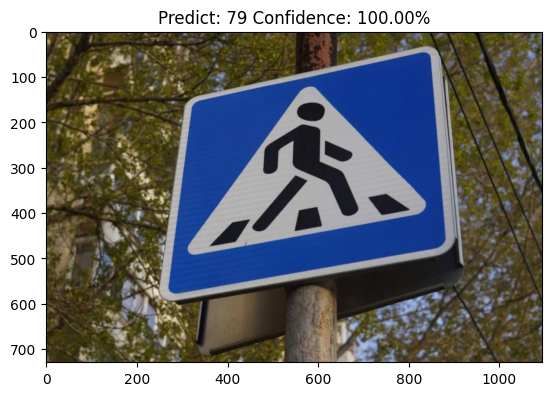

In [13]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Отключаем видимость GPU для PyTorch
import torch
import torchvision.transforms as transforms
from PIL import Image  # Используем PIL для единообразия
import matplotlib.pyplot as plt
import numpy as np

#  Определяем device (CPU или GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# (Предполагаем, что classifier, CLASSIFIER_INPUT_SHAPE, LABELS определены)

# Загрузка модели (УБЕДИТЕСЬ, что модель загружается на CPU, если CUDA недоступна)
try:
    if torch.cuda.is_available():
        classifier.load_state_dict(torch.load('model/cnn_rtsd_final.pt'))
    else:
        classifier.load_state_dict(torch.load('model/cnn_rtsd_final.pt', map_location=torch.device('cpu')))
    print("Модель успешно загружена!")
except FileNotFoundError:
    print("Файл cnn_rtsd_final.pt не найден. Проверьте путь к файлу.")
except RuntimeError as e:
    print(f"Ошибка при загрузке state_dict: {e}")
    print("Убедитесь, что архитектура модели соответствует архитектуре, для которой были сохранены веса.")

# Переносим модель на выбранное устройство
classifier.to(device)
# Переводим модель в режим eval
classifier.eval()

# Определяем преобразования (ИСПОЛЬЗУЕМ ТО ЖЕ, ЧТО И В РАБОЧЕМ КОДЕ!)
transform = transforms.Compose([
    transforms.Resize(CLASSIFIER_INPUT_SHAPE),  #  Размер
    transforms.ToTensor()  # Преобразуем в тензор
    #transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Ваша нормализация (ЕСЛИ ИСПОЛЬЗОВАЛАСЬ)
])

try:
    # Загружаем изображение с использованием PIL (КАК В РАБОЧЕМ КОДЕ!)
    image_path = "workspace_physical/saratov.jpg" # Замените на свой путь
    img = Image.open(image_path).convert('RGB')

    # Преобразуем изображение
    tensor_img = transform(img).to(device)
    tensor_img = tensor_img.unsqueeze(0) # Добавляем batch dimension

    # Отключаем вычисление градиентов
    with torch.no_grad():
        # Получаем предсказания модели
        predict = torch.softmax(classifier(tensor_img).squeeze(), dim=-1)

        # Получаем индекс класса с наибольшей вероятностью и уверенность
        index = torch.argmax(predict).item()
        confidence = predict[index].item()

        # Записываем GROUND TRUTH (исправлено)
        GROUND_TRUTH = torch.tensor([index]).to(device)  # Переносим на то же устройство

        # Выводим результаты
        print(f"Predict: {LABELS[index]} Confidence: {confidence * 100:.2f}%")

        # Отображаем изображение (исправлено)
        plt.imshow(img)  #  Отображаем PIL изображение
        plt.title(f"Predict: {LABELS[index]} Confidence: {confidence * 100:.2f}%")

        # Выводим топ-8 предсказаний
        probs, indices = torch.topk(predict, k=8)
        probs = probs.tolist()
        indices = indices.tolist()

        for i, (indice, p) in enumerate(zip(indices, probs), 1):
            label = LABELS[indice]
            print(f"Top {i} ({p * 100:.2f}%) = {label[:25]} ...")

        # Отображаем график
        plt.show()

except Exception as e:
    print(f"Произошла ошибка: {e}")

# 1.Mask Drawer

In [14]:
"""
1.1 reading target video with lights on victim object
"""
###
SHAPE_RESIZED=(128,128) # influence the resolution of generator and ZOO optimizer
PATH_source="workspace_physical/source.png"
###
source_img = cv2.imread(PATH_source)
source_img = cv2.resize(source_img, SHAPE_RESIZED, interpolation=cv2.INTER_CUBIC)
test_img = source_img.astype(np.float32)/255.0

In [15]:
"""
1.2 record all training target: target_0.mov, target_1.mov ....
"""
import re
target_nums=0
for filename in os.listdir("workspace_physical"):
    pattern_num=re.compile("target_")
    find = re.search(pattern_num, filename)
    if find !=None:
        target_nums+=1
    
print(target_nums)

2


(591, 128, 128, 4)
(591, 128, 128, 3)
(567, 128, 128, 4)
(567, 128, 128, 3)


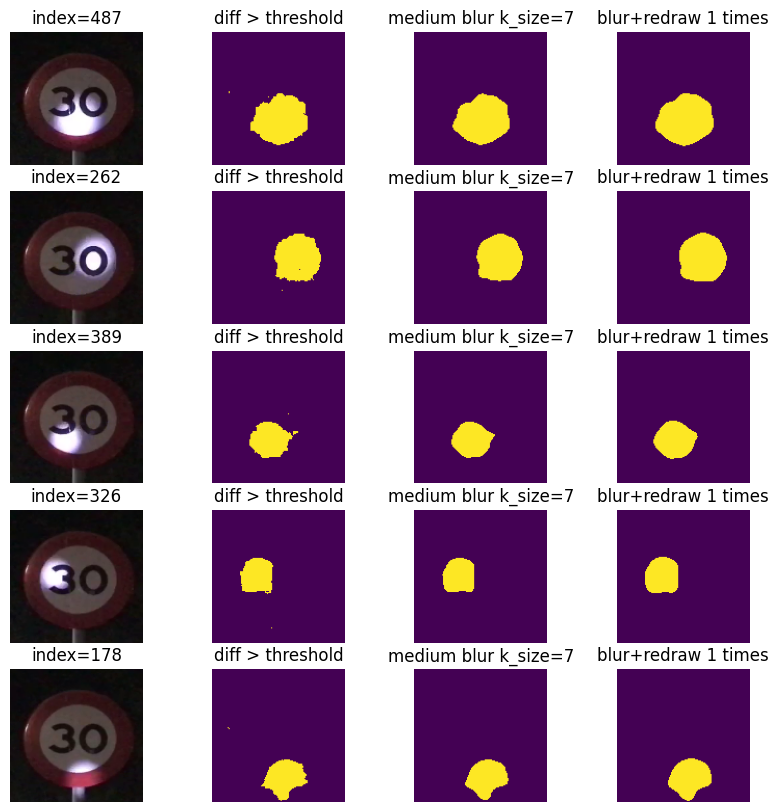

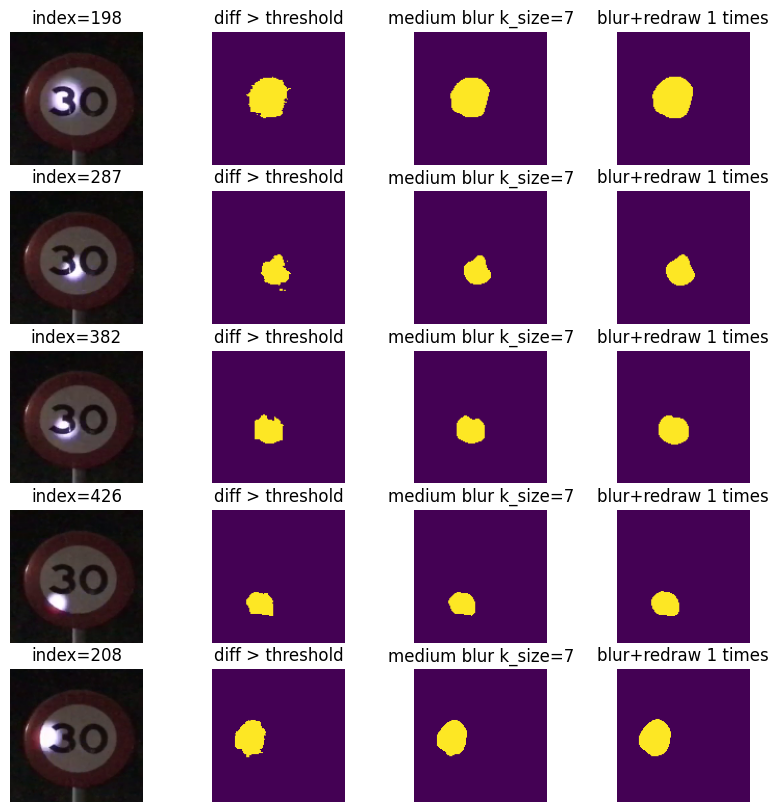

In [16]:
from mask import mask_extract,mask_save,mask_demo
mask_extract(source_img, target_nums, if_rotate,x_bound, y_bound)

In [17]:
"""
1.5 If you satisfy the mask result then concate all existing sub-data you want to train together
"""
mask_save()

Total target(Train) shape= (1158, 128, 128, 3)
Total target( Val ) shape= (127, 128, 128, 3)


# 2. Object-Dependent Light Generator

In [18]:
"""
2.1 Initialize Light Generator 
"""
from model import Generator
###
GENERATOR_MODEL=Generator
GENERATOR_INIT="model/pre_light_generator.pt" # From pre-train stage
###
print("CUDA Available: ", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:",device)

light_generator = GENERATOR_MODEL(gen_input_nc=4, image_nc=3).to(device) # 4 = static+mask
if (GENERATOR_INIT):
     light_generator.load_state_dict(torch.load(GENERATOR_INIT, map_location=torch.device('cpu'))["model_state_dict"])
    

CUDA Available:  False
Device: cpu


In [19]:
"""
2.2 Dataset for training Light Generator 
"""
from light_generator import GAN_dataset
###
PATH_traindata="dataset/physical/train_data.npy"
PATH_traintarget="dataset/physical/train_target.npy"
PATH_valdata="dataset/physical/val_data.npy"
PATH_valtarget="dataset/physical/val_target.npy"
batch_size=16
###
load_augmentation=torchvision.transforms.Compose([torchvision.transforms.ToTensor(),
               #torchvision.transforms.RandomRotation(degrees=(-30,30))
                                                 ])   
load_transform = torchvision.transforms.ToTensor()

train_dataset = GAN_dataset(PATH_traindata,PATH_traintarget,load_augmentation)
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_dataset =  GAN_dataset(PATH_valdata,PATH_valtarget,load_transform)
val_loader = torch.utils.data.DataLoader(val_dataset,batch_size=batch_size,shuffle=True)

In [20]:
"""
2.3 Learning Module of Light Generator
"""
G_criterion = nn.MSELoss()

lr_G = 0.0002
beta1 = 0.5 # Beta1 hyperparam for Adam optimizers

optimizerG = optim.Adam(light_generator.parameters(), lr = lr_G, betas=(beta1, 0.999))
schedulerG = torch.optim.lr_scheduler.StepLR(optimizerG, 100, gamma=0.5)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0047940984..1.0752509].


epoch = 0, G_loss_MSE = 0.00104


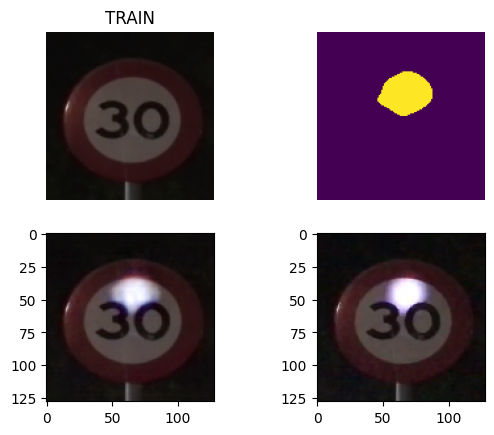

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.020092705..1.084361].


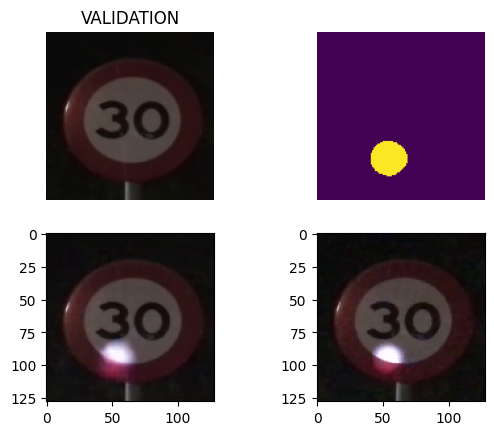

#Validation, G_loss = 0.00119#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.026011761..1.1117313].


epoch = 5, G_loss_MSE = 0.00052


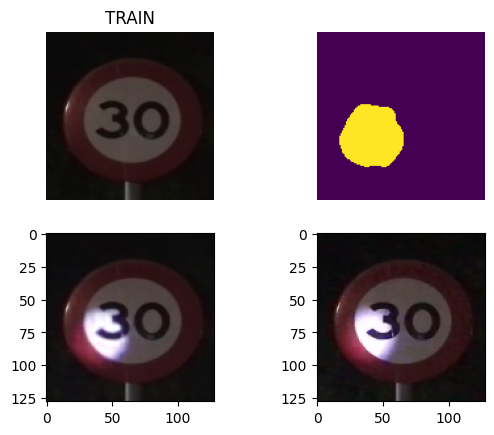

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.014676992..1.114645].


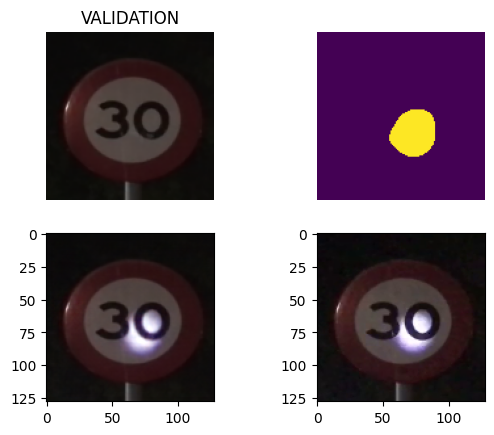

#Validation, G_loss = 0.00050#
epoch = 10, G_loss_MSE = 0.00041


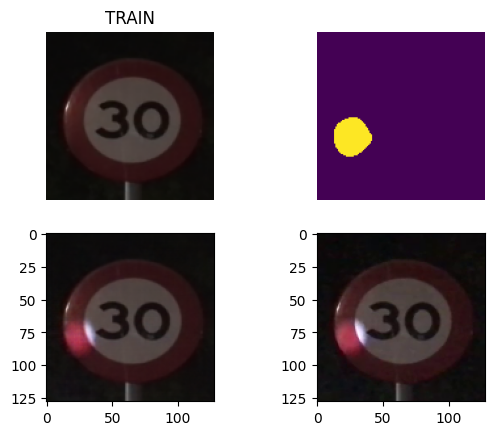

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.013268767..0.9285532].


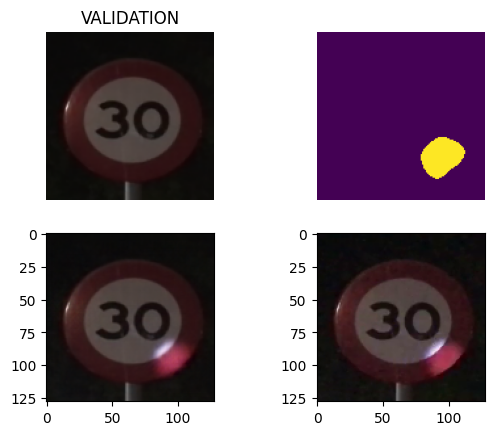

#Validation, G_loss = 0.00043#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.026585523..1.1169072].


epoch = 15, G_loss_MSE = 0.00038


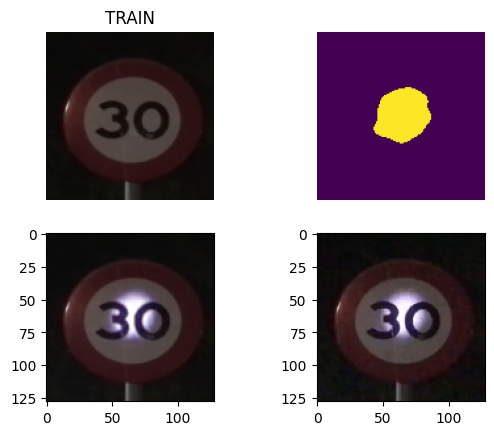

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.4098124e-06..1.1021096].


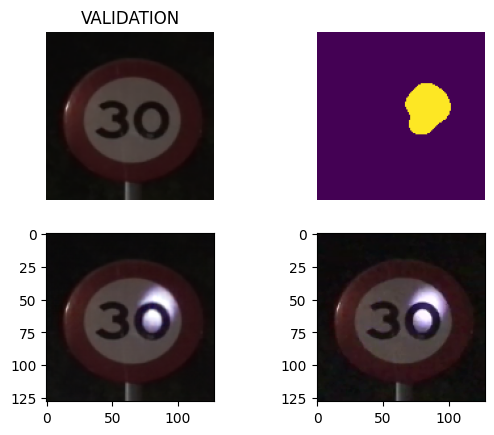

#Validation, G_loss = 0.00040#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.019961786..1.0916986].


epoch = 20, G_loss_MSE = 0.00039


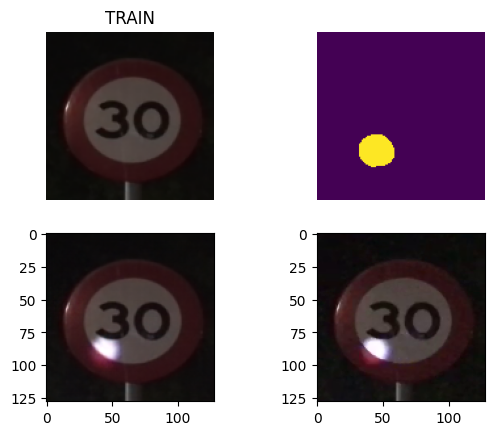

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.021829478..1.07999].


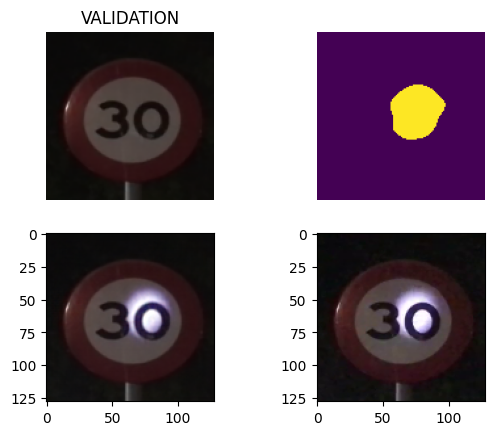

#Validation, G_loss = 0.00037#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0046078265..1.0813562].


epoch = 25, G_loss_MSE = 0.00038


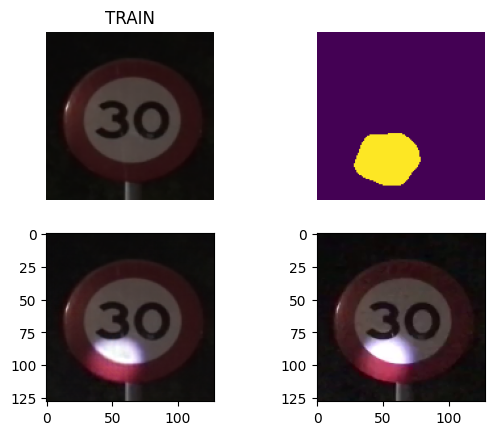

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.021837085..1.139713].


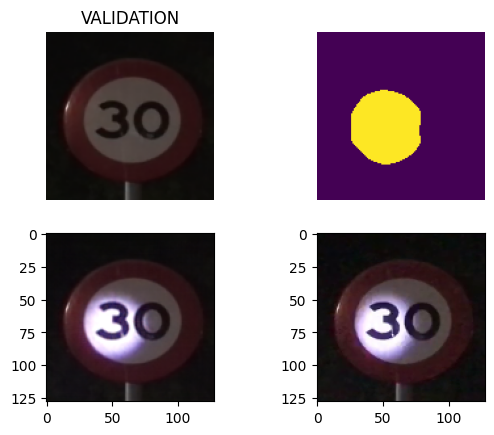

#Validation, G_loss = 0.00046#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0106233..1.1132921].


epoch = 30, G_loss_MSE = 0.00029


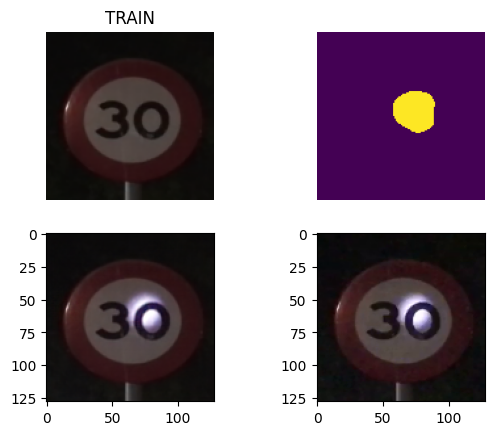

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0036717616..1.026869].


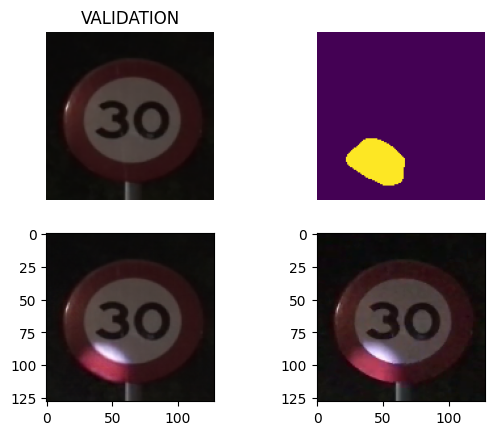

#Validation, G_loss = 0.00037#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0075891074..1.0464035].


epoch = 35, G_loss_MSE = 0.00030


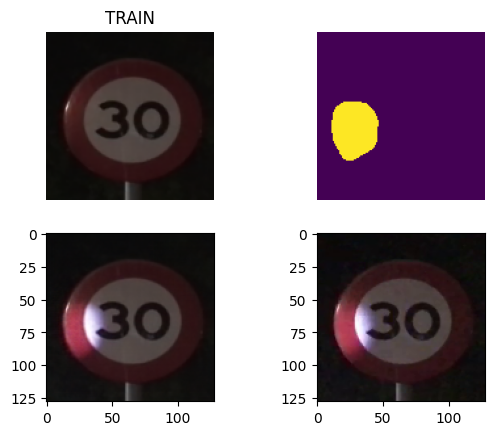

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.024414556..1.0701967].


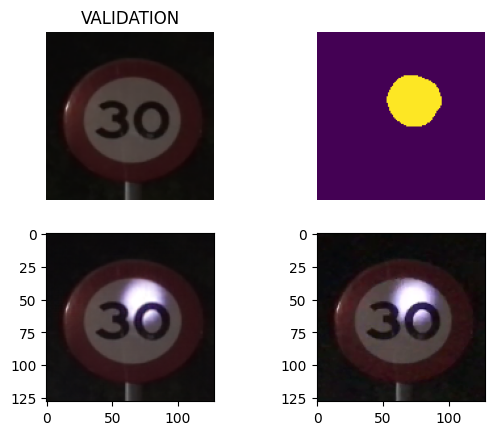

#Validation, G_loss = 0.00032#


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [8.416921e-05..1.0864637].


epoch = 40, G_loss_MSE = 0.00026


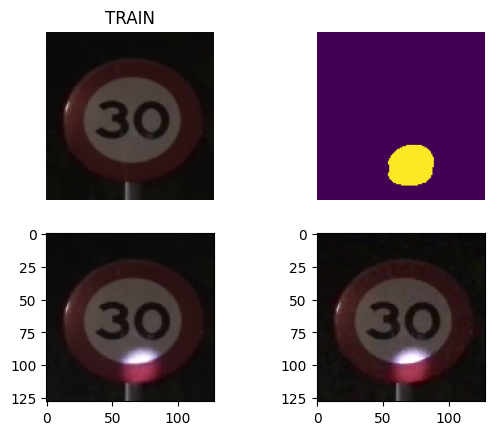

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0035173912..1.0611107].


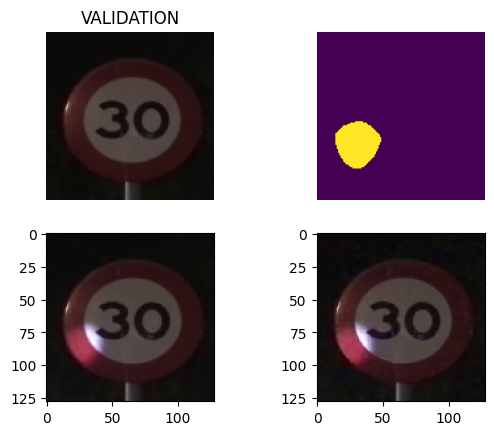

#Validation, G_loss = 0.00032#


In [19]:
from light_generator import train

train(light_generator,optimizerG,schedulerG,G_criterion,train_loader,val_loader,num_epochs=41,Freq_print=5,Freq_plot=5)

In [21]:
"""
ПОПЫТКА ДВА 0.4 Read in victim image and corresponding classification 
"""
"""
1.1 reading target video with lights on victim object
"""
###
SHAPE_RESIZED=(128,128) # influence the resolution of generator and ZOO optimizer
PATH_source="workspace_physical/saratov.jpg"
###
source_img = cv2.imread(PATH_source)
source_img = cv2.resize(source_img, SHAPE_RESIZED, interpolation=cv2.INTER_CUBIC)
test_img = source_img.astype(np.float32)/255.0

[55, 53, 24]


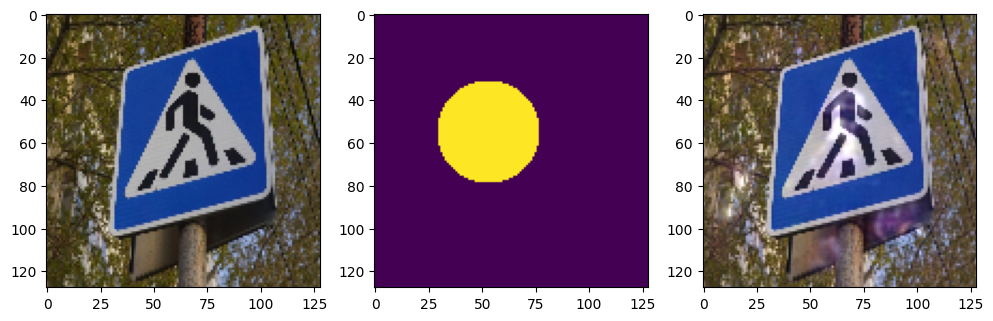

In [24]:
"""
2.5 Demo Light Generator with Random mask
"""
from light_generator import simulate_light_circle,simulate_light_elipse,simulate_light_polygon
###
min_list=[40,40,10] # (x,y,r)
max_list=[80,80,25]
mask_pos=[np.random.randint(min_list[i], max_list[i]) for i in range(len(min_list))]
print(mask_pos)
###



light_generator=GENERATOR_MODEL(gen_input_nc=4, image_nc=3).to(device)
light_generator.load_state_dict(torch.load("model/light_generator.pt", map_location=torch.device('cpu'))["model_state_dict"])
sim,mask=simulate_light_circle(light_generator, source_img, mask_pos)

plt.figure(figsize=(12,12))
plt.subplot(1,3,1)
plt.imshow(source_img[:,:,::-1])

plt.subplot(1,3,2)
plt.imshow(mask)

plt.subplot(1,3,3)
plt.imshow(sim[:,:,::-1])

In [25]:
print(source_img)

[[[ 12  63  73]
  [ 14  61  70]
  [ 20  48  62]
  ...
  [ 51  74  72]
  [ 76  83  81]
  [107 105 104]]

 [[ 12  62  75]
  [ 15  57  76]
  [ 27  49  61]
  ...
  [128 118 115]
  [ 27  67  64]
  [ 94 104 102]]

 [[ 30  80  98]
  [ 16  56  68]
  [ 24  47  54]
  ...
  [143 119 119]
  [ 17  72  72]
  [103 105 110]]

 ...

 [[ 46  80 101]
  [ 27  58  65]
  [ 29  50  56]
  ...
  [ 80  97 102]
  [ 46  73  79]
  [ 41  72  82]]

 [[ 66 102 126]
  [ 35  61  73]
  [ 34  49  58]
  ...
  [ 90  99  93]
  [ 43  70  75]
  [ 40  75  85]]

 [[ 59  95 119]
  [ 35  59  70]
  [ 39  53  65]
  ...
  [ 35  66  71]
  [ 31  60  68]
  [ 49  81  92]]]


# 3.ZOO attack optimizer

In [26]:
from optimize import ZeroOrderOptimizer

###
test_img
criteria = nn.CrossEntropyLoss()
label_attack = GROUND_TRUTH[0]

#############################################################
pos_min_list=[0.3*RESIZED_SHAPE[0], 0.3*RESIZED_SHAPE[1],30] # specify lower bound of each dimension (x1,y1,x2,y2,x3,y3)
pos_max_list=[0.7*RESIZED_SHAPE[0], 0.7*RESIZED_SHAPE[1],10] # specify upper bound of each dimension
###
ZOO_optimizer = ZeroOrderOptimizer(
    source_img, # victim image
    iter=6, # optimize iter of each start point
    label=GROUND_TRUTH.squeeze(),
    attack_model=classifier,
    light_generator=light_generator,
    criteria=criteria, # score criteria
    point_num=5, # number of start point
    draw_light=simulate_light_circle, # draw mask from pos-space to x,y plabe
    min_list=pos_min_list, # lower bound of pos-space
    max_list=pos_max_list, # upper bound of pos-space
    classifier_input_shape=CLASSIFIER_INPUT_SHAPE,
    LABELS=LABELS,
    grad_step=1, # step size to approximate grad(smoothing parameter in ZOO term)
    lr_step=3, # optimize step based on grad
    threshold_restart=0.001 # converge restart threshold
)

Представь, что ты хочешь обмануть учителя, чтобы он не узнал тебя на фотографии. Но ты не можешь замазать лицо или надеть маску. Ты можешь только немного изменить освещение на фотографии.

**Задача:** Найти, где и какого размера поставить "фонарик" на картинке, чтобы нейросеть (наш "учитель") перестала узнавать на ней нужный объект.

**Как это делается:**

1. **"Кандидаты" (Point):** У нас есть несколько "хулиганов" (Point), каждый из которых пытается по-своему обмануть нейросеть. Каждый "хулиган" выбирает случайное место и размер для своего "фонарика".

2. **"Фонарик" (simulate_light_circle):** Каждый "хулиган" берёт картинку и с помощью специальной функции (simulate_light_circle) рисует на ней круг света (наш "фонарик") в выбранном месте и заданного размера.

3. **"Обман" (light_inference):** Теперь нужно проверить, получилось ли обмануть нейросеть. Мы показываем нейросети картинку с "фонариком" и смотрим, что она скажет.

   * Если нейросеть ошиблась (не узнала объект), значит "хулиган" был близок к цели!
   * Если нейросеть всё ещё узнаёт объект, значит "фонарик" нужно подвинуть или изменить его размер.

4. **"Подсказки" (find_grad):** Чтобы понять, куда двигать "фонарик", каждый "хулиган" делает небольшие пробные шаги:

   * Чуть-чуть двигает "фонарик" вправо и смотрит, стало лучше или хуже обманывать нейросеть.
   * Чуть-чуть двигает "фонарик" влево и смотрит, стало лучше или хуже.
   * И так далее для движения вверх, вниз, и изменения размера "фонарика".

   Сравнивая результаты, "хулиган" понимает, в какую сторону нужно двигать "фонарик", чтобы обмануть нейросеть. Это похоже на то, как ты ищешь выход из лабиринта, пробуя разные пути.

5. **"Движение" (update_pos):** "Хулиган" делает небольшой шаг в направлении, которое, по его мнению, поможет обмануть нейросеть. Он двигает "фонарик" и немного меняет его размер.

6. **Повторение (run):** Шаги 2-5 повторяются много раз. Каждый "хулиган" пробует разные места и размеры для своего "фонарика", пока один из них не сможет успешно обмануть нейросеть.

7. **"Усталость" (threshold_restart):** Иногда "хулиган" застревает в плохом месте, где никак не получается обмануть нейросеть. Тогда он решает начать всё сначала и выбирает новое случайное место для своего "фонарика".

**Главная идея:**

*   Мы не знаем, как именно работает нейросеть и какие места на картинке для неё самые важные.
*   Поэтому мы пробуем разные варианты "фонариков" и смотрим, какие из них заставляют нейросеть ошибаться.
*   Мы используем небольшие пробные шаги, чтобы понять, в какую сторону нужно двигать "фонарик", чтобы увеличить вероятность обмана.

В итоге, с помощью проб и ошибок, мы находим такое положение и размер "фонарика", которое сбивает нейросеть с толку и заставляет её ошибаться. И всё это без знания внутренней работы нейросети!


In [27]:
ZOO_optimizer.run()

17
Confidence: 71.13519310951233 %
best pos [np.int16(66), np.int16(80), np.int16(10)]
Largest Loss 4.943469047546387


True

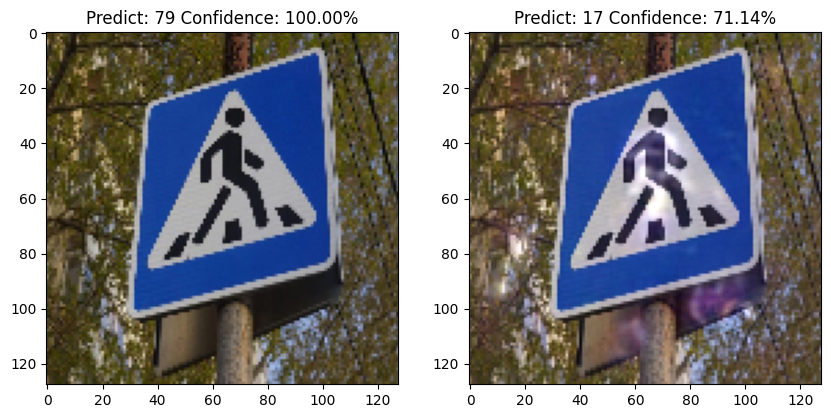

In [28]:
"""
3.5 Demo of ZOO optimize result 
"""
print(LABELS[ZOO_optimizer.predict])
print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
print("best pos", ZOO_optimizer.global_best_pos)
print("Largest Loss",ZOO_optimizer.global_best_value)

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[ZOO_optimizer.predict], ZOO_optimizer.confidence.item()*100))
plt.imshow(ZOO_optimizer.attack_img[:,:,::-1])

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))

17
Confidence: 71.13519310951233 %
best pos [np.int16(66), np.int16(80), np.int16(10)]
Largest Loss 4.943469047546387


True

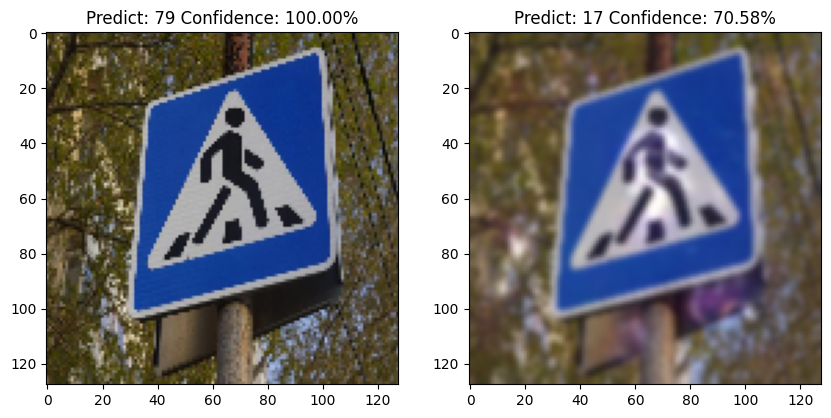

In [29]:
"""
3.5 Demo of ZOO optimize result + ГАУСС
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np

print(LABELS[ZOO_optimizer.predict])
print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
print("best pos", ZOO_optimizer.global_best_pos)
print("Largest Loss",ZOO_optimizer.global_best_value)

# Apply Gaussian blur to the attacked image
blurred_attack_img = cv2.GaussianBlur(ZOO_optimizer.attack_img, (5, 5), 0) # kernel size 5x5, sigma=0

# Re-evaluate with the blurred image
classifier.eval()
resize_img = cv2.resize(blurred_attack_img, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)

predict_blurred = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_blurred = torch.argmax(predict_blurred).item()
confidence_blurred = predict_blurred[index_blurred].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index_blurred], confidence_blurred*100))
plt.imshow(blurred_attack_img[:,:,::-1])

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/blurred_sim_light.png', (blurred_attack_img*255).clip(0,255).astype("uint8")[:,:,::-1])

17
Confidence: 71.13519310951233 %
best pos [np.int16(66), np.int16(80), np.int16(10)]
Largest Loss 4.943469047546387


True

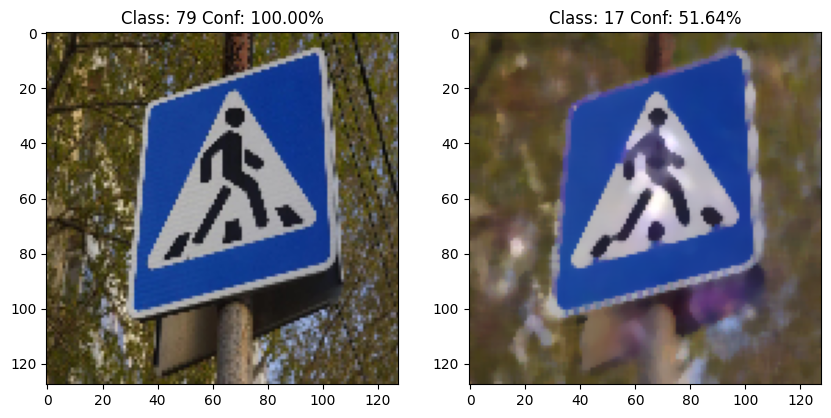

In [30]:
"""
3.5 Demo of ZOO optimize result + МЕДИАННЫЙ
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np

print(LABELS[ZOO_optimizer.predict])
print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
print("best pos", ZOO_optimizer.global_best_pos)
print("Largest Loss",ZOO_optimizer.global_best_value)

# Apply Median blur to the attacked image
blurred_attack_img = cv2.medianBlur(ZOO_optimizer.attack_img, 5) # kernel size 5

# Re-evaluate with the blurred image
classifier.eval()
resize_img = cv2.resize(blurred_attack_img, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)

predict_blurred = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_blurred = torch.argmax(predict_blurred).item()
confidence_blurred = predict_blurred[index_blurred].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index_blurred], confidence_blurred*100))
plt.imshow(blurred_attack_img[:,:,::-1])

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/median_blurred_sim_light.png', (blurred_attack_img*255).clip(0,255).astype("uint8")[:,:,::-1])

Min/Max values after CLAHE: 5, 255
Min/Max normalized values: 0.0196078431372549, 1.0
Min/Max values after color transformation: 0, 255


True

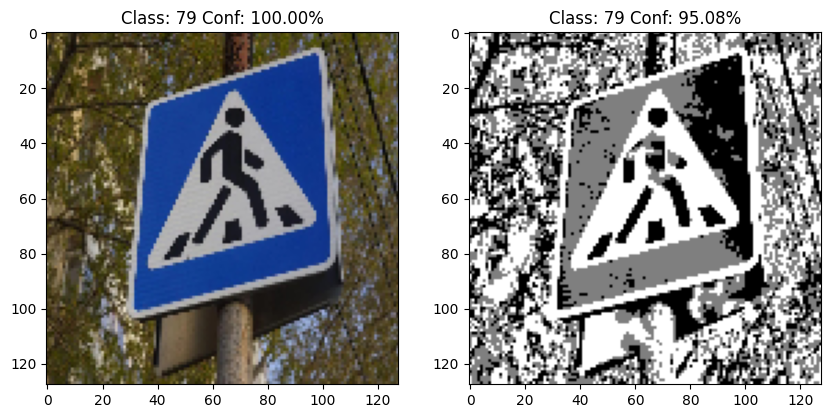

In [33]:
"""
3.5 Demo of ZOO optimize result + Контраст и цветовая палитра (исправлено)
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torchvision

#print(LABELS[ZOO_optimizer.predict])
#print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
#print("best pos", ZOO_optimizer.global_best_pos)
#print("Largest Loss",ZOO_optimizer.global_best_value)

# 1. Convert to grayscale
gray_attack_img = cv2.cvtColor(ZOO_optimizer.attack_img, cv2.COLOR_BGR2GRAY)

# 2. Enhance contrast (using CLAHE - Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))  # Adjust parameters as needed

# Scale to 0-255 and convert to uint8 for CLAHE
gray_attack_img_scaled = (gray_attack_img * 255).clip(0, 255).astype(np.uint8)

contrast_enhanced_img = clahe.apply(gray_attack_img_scaled)

# Check the range of values after CLAHE
print(f"Min/Max values after CLAHE: {np.min(contrast_enhanced_img)}, {np.max(contrast_enhanced_img)}")

# 3. Change the color palette
# Create a 3-channel image
color_transformed_img = np.zeros((contrast_enhanced_img.shape[0], contrast_enhanced_img.shape[1], 3), dtype=np.uint8)

# Normalize values to 0-1 range (instead of 0-100)
normalized_img = contrast_enhanced_img / 255.0

# Check the range of normalized values
print(f"Min/Max normalized values: {np.min(normalized_img)}, {np.max(normalized_img)}")

# Apply the color transformation rules
color_transformed_img[normalized_img <= 0.3] = [0, 0, 0]  # Black for brightness 0-10%
color_transformed_img[(normalized_img > 0.3) & (normalized_img <= 0.5)] = [127, 127, 127]  # Gray for brightness 10-50%
color_transformed_img[normalized_img > 0.5] = [255, 255, 255]  # White for brightness 50-100%

# Check the range of values after color transformation
print(f"Min/Max values after color transformation: {np.min(color_transformed_img)}, {np.max(color_transformed_img)}")

# 4. Re-evaluate with the transformed image
classifier.eval()
resize_img = cv2.resize(color_transformed_img, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)

predict_transformed = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_transformed = torch.argmax(predict_transformed)
confidence_transformed = predict_transformed[index_transformed].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Class: {} Conf: {:.2f}%".format(LABELS[index_transformed], confidence_transformed*100))
plt.imshow(cv2.cvtColor(color_transformed_img, cv2.COLOR_BGR2RGB))  # Display as RGB

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/color_transformed_sim_light.png', color_transformed_img)

True

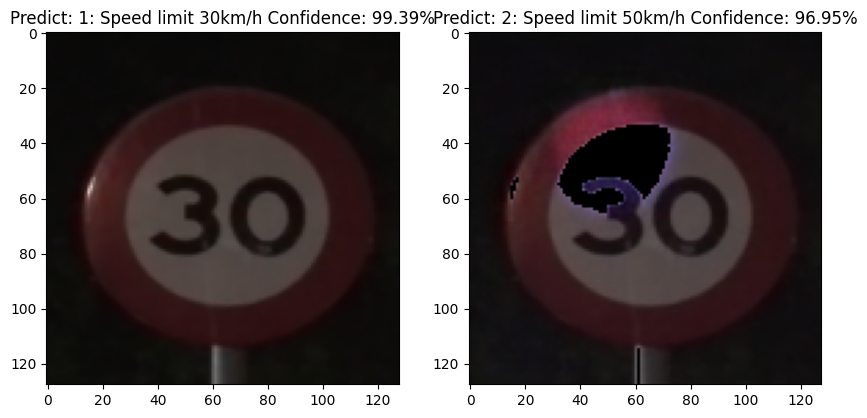

In [47]:
"""
3.5 Demo of ZOO optimize result
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torchvision

# 1. Divide the image into 9 parts
def calculate_mean_intensity(image):
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return np.mean(gray_img)

height, width, _ = ZOO_optimizer.attack_img.shape
part_height = height // 3
part_width = width // 3

intensities = []
for i in range(3):
    for j in range(3):
        y1 = i * part_height
        y2 = (i + 1) * part_height
        x1 = j * part_width
        x2 = (j + 1) * part_width
        part = ZOO_optimizer.attack_img[y1:y2, x1:x2]
        intensities.append(calculate_mean_intensity(part))

# 3. Calculate the average intensity of the middle three intensities
sorted_intensities = sorted(intensities)
middle_intensities = sorted_intensities[3:6]  # Exclude top 3 and bottom 3
mean_intensity = np.mean(middle_intensities)

# 4. Find the brightest pixels (e.g., top 10% brightest)
gray_attack_img = cv2.cvtColor(ZOO_optimizer.attack_img, cv2.COLOR_BGR2GRAY)
threshold_intensity = np.percentile(gray_attack_img, 95)  # Adjust 90% as needed
bright_pixels = gray_attack_img > threshold_intensity

# 5. Replace bright pixels with the calculated mean intensity
modified_attack_img = (ZOO_optimizer.attack_img * 255).copy().astype(np.float32) # Scale to 0-255, use float32
modified_attack_img[bright_pixels] = mean_intensity  # Replace
modified_attack_img = np.clip(modified_attack_img, 0, 255).astype(np.uint8) # Clip to valid range

# Re-evaluate with the modified image
classifier.eval()
resize_img = cv2.resize(modified_attack_img/255, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC) # Normalize to 0-1 before resize
resize_img = resize_img.astype(np.float32)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)
tensor_img = tensor_img.float()

predict_modified = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_modified = torch.argmax(predict_modified).item()
confidence_modified = predict_modified[index_modified].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index_modified], confidence_modified*100))
plt.imshow(modified_attack_img[:,:,::-1])

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/modified_sim_light.png', modified_attack_img[:,:,::-1])

6: End of speed limit 80km/h
Confidence: 96.27695083618164 %
best pos [45.16504902 51.84324372 24.74682462]
Largest Loss 7.275816440582275


True

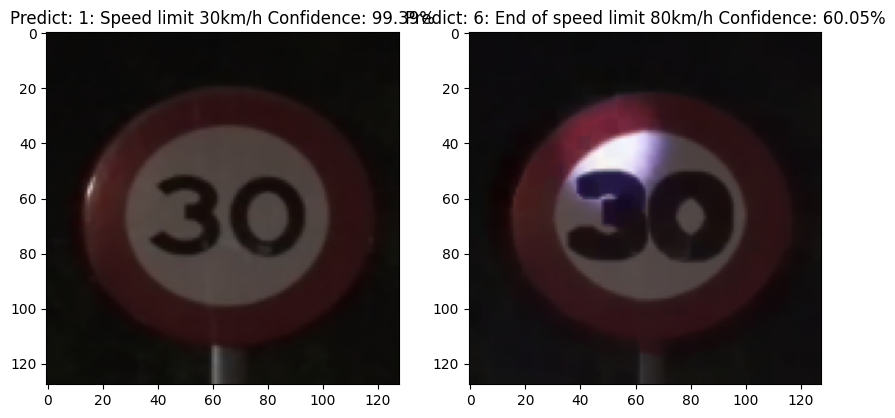

In [26]:
"""
3.5 Demo of ZOO optimize result + ЭРОЗИЯ
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np

print(LABELS[ZOO_optimizer.predict])
print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
print("best pos", ZOO_optimizer.global_best_pos)
print("Largest Loss",ZOO_optimizer.global_best_value)

# Apply Erosion to the attacked image
kernel = np.ones((5, 5), np.uint8)  # Define the kernel for erosion
eroded_attack_img = cv2.erode(ZOO_optimizer.attack_img, kernel, iterations=1)  # Apply erosion

# Re-evaluate with the eroded image
classifier.eval()
resize_img = cv2.resize(eroded_attack_img, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)

predict_eroded = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_eroded = torch.argmax(predict_eroded).item()
confidence_eroded = predict_eroded[index_eroded].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index_eroded], confidence_eroded*100))
plt.imshow(eroded_attack_img[:,:,::-1])

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/eroded_sim_light.png', eroded_attack_img[:,:,::-1])

6: End of speed limit 80km/h
Confidence: 96.27695083618164 %
best pos [45.16504902 51.84324372 24.74682462]
Largest Loss 7.275816440582275


True

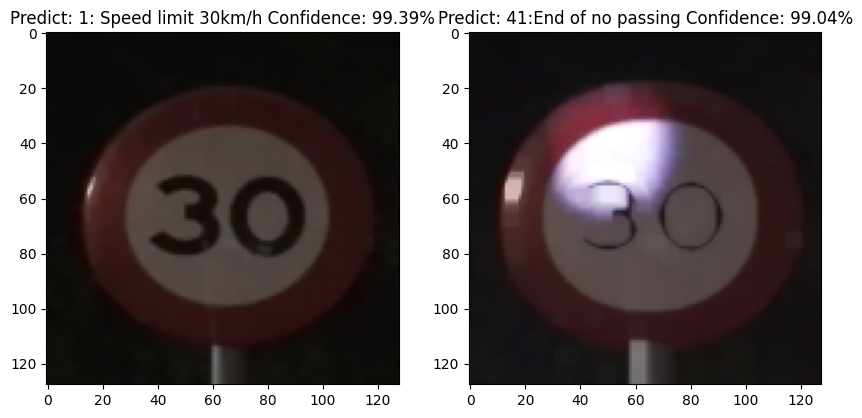

In [27]:
"""
3.5 Demo of ZOO optimize result + НАРАЩИВАНИЕ
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np

print(LABELS[ZOO_optimizer.predict])
print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
print("best pos", ZOO_optimizer.global_best_pos)
print("Largest Loss",ZOO_optimizer.global_best_value)

# Apply Dilation to the attacked image
kernel = np.ones((5, 5), np.uint8)  # Define the kernel for dilation
dilated_attack_img = cv2.dilate(ZOO_optimizer.attack_img, kernel, iterations=1)  # Apply dilation

# Re-evaluate with the dilated image
classifier.eval()
resize_img = cv2.resize(dilated_attack_img, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)

predict_dilated = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_dilated = torch.argmax(predict_dilated).item()
confidence_dilated = predict_dilated[index_dilated].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index_dilated], confidence_dilated*100))
plt.imshow(dilated_attack_img[:,:,::-1])

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/dilated_sim_light.png', dilated_attack_img[:,:,::-1])

6: End of speed limit 80km/h
Confidence: 96.27695083618164 %
best pos [45.16504902 51.84324372 24.74682462]
Largest Loss 7.275816440582275


True

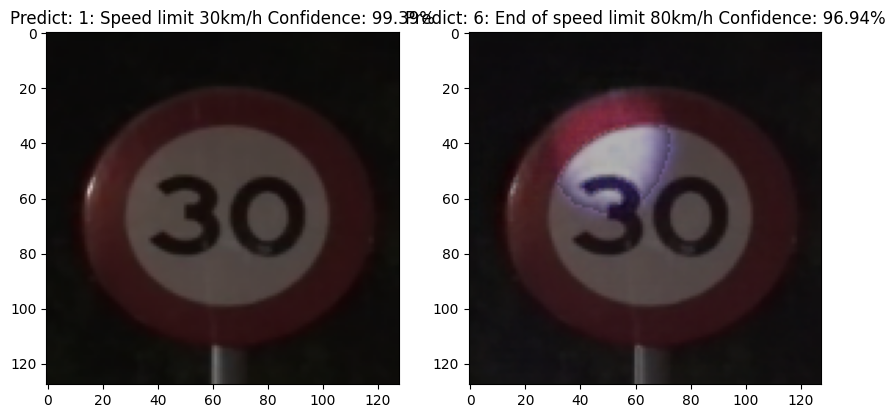

In [35]:
"""
3.5 Demo of ZOO optimize result + Затемнение засвеченной области
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torchvision

print(LABELS[ZOO_optimizer.predict])
print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
print("best pos", ZOO_optimizer.global_best_pos)
print("Largest Loss",ZOO_optimizer.global_best_value)

# 1. Convert to grayscale (for easier identification of bright regions)
gray_attack_img = cv2.cvtColor(ZOO_optimizer.attack_img, cv2.COLOR_BGR2GRAY)

# 2. Identify Overexposed (Bright) Regions
threshold = np.percentile(gray_attack_img, 95)  # Adjust threshold (e.g., 95th percentile)
overexposed_mask = gray_attack_img > threshold

# 3. Apply Brightness Reduction to Overexposed Regions
modified_attack_img = (ZOO_optimizer.attack_img * 255).copy().astype(np.float32)  # Use float32 for calculations
brightness_reduction = 0.3  # Reduce brightness by 0% (adjust as needed)
modified_attack_img[overexposed_mask] *= (1 - brightness_reduction)

# 4. Clip and convert back to uint8
modified_attack_img = np.clip(modified_attack_img, 0, 255).astype(np.uint8)

# Re-evaluate with the modified image
classifier.eval()
resize_img = cv2.resize(modified_attack_img/255, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
resize_img = resize_img.astype(np.float32) # Ensure float32
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)
tensor_img = tensor_img.float()

predict_modified = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_modified = torch.argmax(predict_modified).item()
confidence_modified = predict_modified[index_modified].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index_modified], confidence_modified*100))
plt.imshow(modified_attack_img[:,:,::-1])

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/darkened_sim_light.png', modified_attack_img[:,:,::-1])

6: End of speed limit 80km/h
Confidence: 96.27695083618164 %
best pos [45.16504902 51.84324372 24.74682462]
Largest Loss 7.275816440582275


True

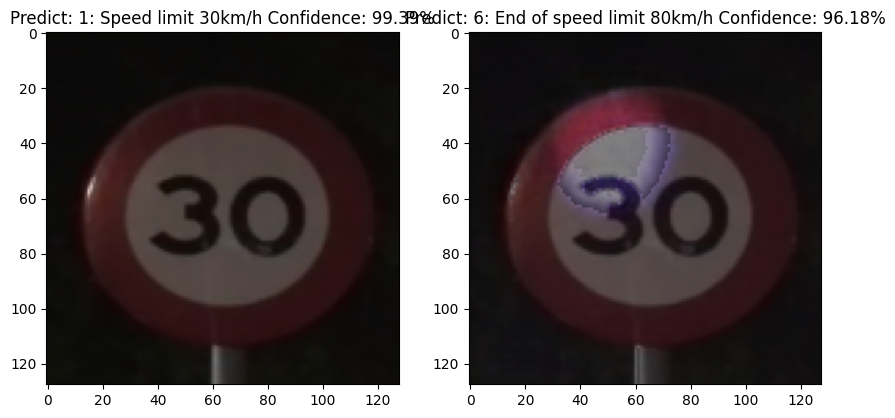

In [43]:
"""
3.5 Demo of ZOO optimize result + Затемнение засвеченной области с разными процентами
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
import torchvision

print(LABELS[ZOO_optimizer.predict])
print(f"Confidence: {ZOO_optimizer.confidence.item()*100} %")
print("best pos", ZOO_optimizer.global_best_pos)
print("Largest Loss",ZOO_optimizer.global_best_value)

# 1. Convert to grayscale (for easier identification of bright regions)
gray_attack_img = cv2.cvtColor(ZOO_optimizer.attack_img, cv2.COLOR_BGR2GRAY)

# 2. Identify Overexposed (Bright) Regions and Apply Different Brightness Reductions
modified_attack_img = (ZOO_optimizer.attack_img * 255).copy().astype(np.float32)  # Use float32 for calculations

# First, darken pixels with brightness > 98% by 50%
threshold_98 = np.percentile(gray_attack_img, 98)
overexposed_mask_98 = gray_attack_img > threshold_98
modified_attack_img[overexposed_mask_98] *= (1 - 0.5)  # 50% reduction

# Second, darken pixels with brightness between 95% and 98% by 30%
threshold_95 = np.percentile(gray_attack_img, 95)
overexposed_mask_95_98 = (gray_attack_img > threshold_95) & (gray_attack_img <= threshold_98)
modified_attack_img[overexposed_mask_95_98] *= (1 - 0.4)  # 30% reduction

# 3. Clip and convert back to uint8
modified_attack_img = np.clip(modified_attack_img, 0, 255).astype(np.uint8)

# Re-evaluate with the modified image
classifier.eval()
resize_img = cv2.resize(modified_attack_img/255, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
resize_img = resize_img.astype(np.float32) # Ensure float32
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)
tensor_img = tensor_img.float()

predict_modified = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_modified = torch.argmax(predict_modified).item()
confidence_modified = predict_modified[index_modified].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index],confidence*100))
plt.imshow(test_img[:,:,::-1])

plt.subplot(122)
plt.title("Predict: {} Confidence: {:.2f}%".format(LABELS[index_modified], confidence_modified*100))
plt.imshow(modified_attack_img[:,:,::-1])

cv2.imwrite('workspace/sim_light.png', (ZOO_optimizer.attack_img*255).clip(0,255).astype("uint8"))
cv2.imwrite('workspace/darkened_sim_light_multi.png', modified_attack_img[:,:,::-1])

# 4. Into Physical

True

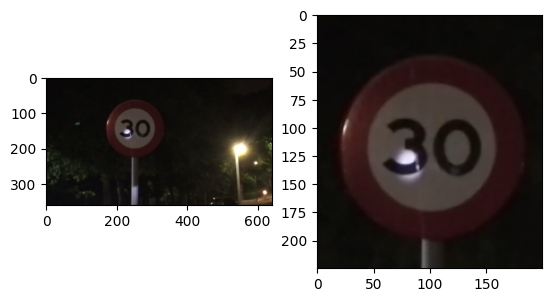

In [23]:
# !!! Due to the run to run variance your result might differ.
"""
4.1 video to image reduce noise(or skip this part use png only) 
"""
cap = cv2.VideoCapture("workspace_physical/physical.mov")
frame_list=[]
while(cap.isOpened()):
    ret, frame = cap.read()
    
    if ret == True:
        if if_rotate:
            frame=cv2.rotate(frame, cv2.ROTATE_90_COUNTERCLOCKWISE)
        frame_list.append(frame)
    else:
        break
cap.release()

static_img=np.mean(frame_list,axis=0) # mean of multi frames to reduce noise
static_img=np.round(static_img)/255
plt.subplot(1,2,1)
plt.imshow(static_img[:,:,::-1])
plt.subplot(1,2,2)
plt.imshow(static_img[x_bound[0]:x_bound[1],y_bound[0]:y_bound[1]][:,:,::-1])

test_img=static_img[x_bound[0]:x_bound[1],y_bound[0]:y_bound[1]]
cv2.imwrite('workspace_physical/physical.png', (test_img*255).astype("uint8"))

Text(0.5, 1.0, '2: Speed limit 50km/h... Confidence: 99.90%')

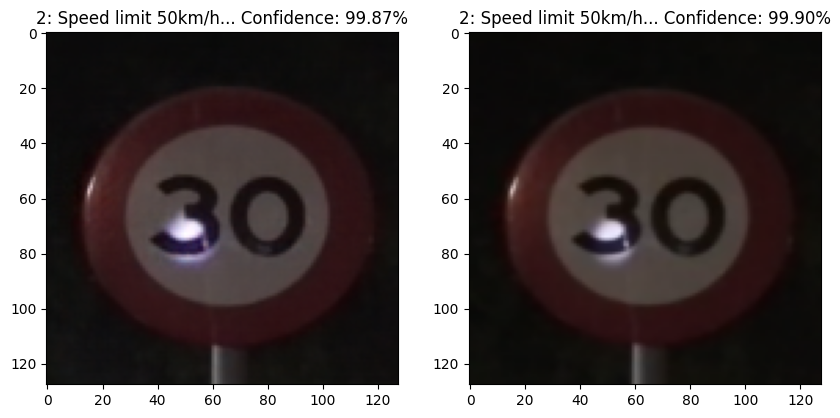

In [25]:
"""
4.2 Inference physical image to evaluate simulation and physical attack 
"""
###
physical_img_ = cv2.imread("workspace_physical/physical.png")
###
physical_img = cv2.resize(physical_img_, RESIZED_SHAPE, interpolation=cv2.INTER_AREA)
physical_img=physical_img.astype(np.float32)/255

classifier.eval()
resize_img = cv2.resize(physical_img, CLASSIFIER_INPUT_SHAPE, interpolation=cv2.INTER_CUBIC)
tensor_img = torchvision.transforms.ToTensor()(resize_img).unsqueeze(0).to(device)

predict_phy = torch.softmax(classifier.forward(tensor_img).squeeze(), dim=-1)

index_phy = torch.argmax(predict_phy).item()
confidence_phy = predict_phy[index_phy].item()

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.title("{}... Confidence: {:.2f}%".format(LABELS[ZOO_optimizer.predict][:25], ZOO_optimizer.confidence.item()*100))
plt.imshow(ZOO_optimizer.attack_img[:,:,::-1])

plt.subplot(122)
plt.imshow(physical_img[:,:,::-1])
plt.title("{}... Confidence: {:.2f}%".format(LABELS[index_phy][:25],confidence_phy*100))